# Color Sensitive Blurring using PyTorch

In [45]:
import torchimport torch.nn.functional as Fimport numpy as npimport matplotlib.pyplot as pltfrom PIL import Imagefrom sklearn.metrics import classification_reportimport json

## Load Image

In [46]:
img = Image.open("D:\Conv\sample.jpg").convert("RGB")img_np = np.array(img) / 255.0img_tensor = torch.tensor(img_np).permute(2,0,1).unsqueeze(0).float()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\leohi\AppData\Local\Temp\ipykernel_19644\1484834745.py:1: SyntaxWarning: invalid escape sequence '\C'
  img = Image.open("D:\Conv\sample.jpg").convert("RGB")


## Create Gaussian Kernel

In [47]:
def gaussian_kernel(size=15, sigma=5.0):    ax = torch.arange(-(size // 2), size // 2 + 1, dtype=torch.float32)    xx, yy = torch.meshgrid(ax, ax)       kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))    kernel = kernel / kernel.sum()    return kernelkernel = gaussian_kernel(15, 5.0)kernel = kernel.unsqueeze(0).unsqueeze(0)   kernel = kernel.repeat(3,1,1,1)             

## Apply Blur

In [48]:
blurred = F.conv2d(img_tensor, kernel, padding=7, groups=3)

## Color Mask (Red Detection)

In [49]:
r = img_np[:,:,0]g = img_np[:,:,1]b = img_np[:,:,2]mask = (r > 0.4) & (r > g + 0.1) & (r > b + 0.1)mask = mask.astype(np.float32)mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

## Apply Selective Blur

In [50]:
final = img_tensor * (1 - mask_tensor) + blurred * mask_tensor

## Display Output

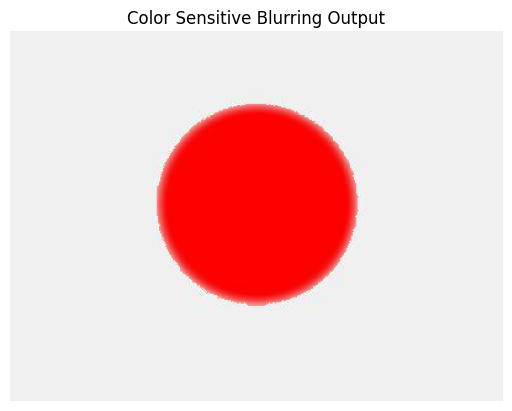

In [51]:
final_img = final.squeeze(0).permute(1,2,0).detach().numpy()plt.imshow(final_img)plt.title("Color Sensitive Blurring Output")plt.axis('off')plt.show()

## Evaluation (Classification Report)

In [52]:
y_true = mask.flatten()y_pred = (mask > 0.5).flatten()report = classification_report(y_true, y_pred, output_dict=True)with open("classification_report.json", "w") as f:    json.dump(report, f, indent=4)print("Classification report saved!")

Classification report saved!


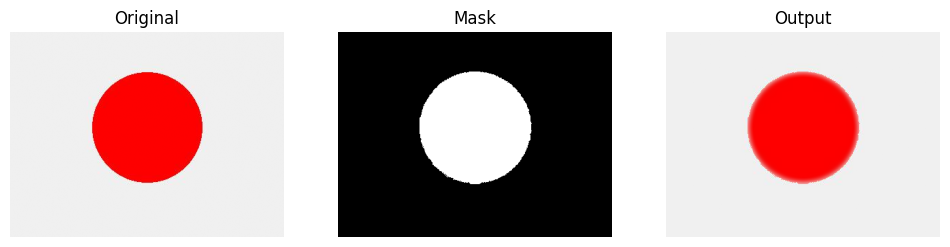

In [53]:
fig, ax = plt.subplots(1,3, figsize=(12,4))ax[0].imshow(img_np)ax[0].set_title("Original")ax[0].axis('off')ax[1].imshow(mask, cmap='gray')ax[1].set_title("Mask")ax[1].axis('off')ax[2].imshow(final_img)ax[2].set_title("Output")ax[2].axis('off')plt.show()